# TP — Web Sémantique & Machine Learning
## Prédire le succès commercial d'un film
Le fichier n3 de films devient un graphe RDF
interrogeable en SPARQL, qui alimente un pipeline de Machine Learning.

```
N3 → graphe RDF (RDFLib) → SPARQL → NumPy → sklearn → outliers → Wikidata
```

**Règle métier :** un film est un **succès** si `recettes > 2 × budget` (le retour sur investssement ROI > 2).

| Partie | Contenu |
|--------|---------|
| 1 | N3 → graphe RDF (RDF · RDFS · DC · FOAF) |
| 2 | Explorer avec SPARQL |
| 3 | Extraire les données vers NumPy |
| 4 | Normaliser et classifier (DT · KNN · NB) |
| 5 | Clustering sans labels (K-Means · DBSCAN · CAH) |
| 6 | Confronter avec Wikidata |


## Partie 0 — Imports

In [2]:
!pip install rdflib
!pip install graphviz


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\demar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\demar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import csv, urllib.request, urllib.parse, json
from rdflib import Graph, Namespace, Literal, URIRef, RDF, RDFS, XSD
from rdflib.namespace import FOAF, DC, DCTERMS
from rdflib.plugins.sparql import prepareQuery

import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, classification_report,
                             adjusted_rand_score, normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score, silhouette_score, davies_bouldin_score)

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

from rdflib.tools.rdf2dot import rdf2dot
import graphviz

import warnings; warnings.filterwarnings("ignore")


---
## Partie 1 —  Du N3 au graphe RDF

Récupérer le fichier films_data_normes.n3 et le placer dans le même répertoire.
Expliquer ce que dit ce fichier. Les informations de ce fichiers sont des informations synthétiques, créées spécifiquement pour ce TP, rien n'est supposé vrai ni n'a été vérifié.

In [5]:
# Création du graphe
g = Graph()

CIN    = Namespace("http://cinema.fr/vocab#")
FILM   = Namespace("http://cinema.fr/film#")
GENRE  = Namespace("http://cinema.fr/genre#")
SAISON = Namespace("http://cinema.fr/saison#")

# Graphe + préfixes (raccourcis pour la sérialisation)
for prefix, ns in [("rdf",RDF),("rdfs",RDFS),("dc",DC),
                   ("dcterms",DCTERMS),("foaf",FOAF),
                   ("cin",CIN),("film",FILM),("genre",GENRE),("saison",SAISON)]:
    g.bind(prefix, ns)

# Chargement du fichier N3
g.parse("./films_data.n3", format="n3", encoding="utf-8")

# Affichage du nombre de triplets
print(f"Nombre de triplets dans le graphe : {len(g)}")


print(f"\n✓ Base de connaissances créée avec {len(g)} triplets RDF")
print("\nExemple de quelques triplets :")
for i, (s, p, o) in enumerate(g):
    if i < 5:
        print(f"  {s} -> {p} -> {o}")

Nombre de triplets dans le graphe : 1376

✓ Base de connaissances créée avec 1376 triplets RDF

Exemple de quelques triplets :
  http://cinema.fr/film#F049 -> http://purl.org/dc/elements/1.1/title -> IT Chapter 2
  http://cinema.fr/film#F023 -> http://cinema.fr/vocab#label -> 1
  http://cinema.fr/film#F023 -> http://xmlns.com/foaf/0.1/name -> Spider-Man Homecoming
  http://cinema.fr/film#F050 -> http://purl.org/dc/elements/1.1/subject -> http://cinema.fr/genre#drame
  http://cinema.fr/film#F085 -> http://www.w3.org/1999/02/22-rdf-syntax-ns#type -> http://cinema.fr/vocab#FilmEchec


Visualisation du graphe


(process:1252): Pango-WARNING **: 10:40:50.099: couldn't load font "DejaVu Sans Bold Not-Rotated 14", falling back to "Sans Bold Not-Rotated 14", expect ugly output.

(process:1252): Pango-WARNING **: 10:40:50.151: couldn't load font "DejaVu Sans Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.

(process:1252): Pango-WARNING **: 10:40:50.174: couldn't load font "DejaVu Sans Not-Rotated 14", falling back to "Sans Not-Rotated 14", expect ugly output.


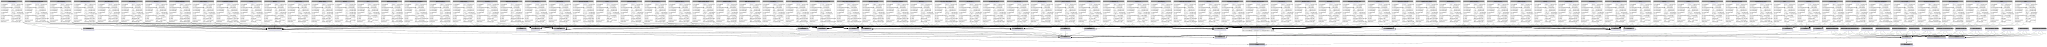

In [6]:
with open("graph.dot", "w") as f:
    rdf2dot(g, f)

# puis afficher
with open("graph.dot") as f:
    dot_graph = f.read()

graphviz.Source(dot_graph)

EXERCICE 1 :

⛳ TODO Expliciter la BDD
- remarques ? analyses ?

---
## Partie 2 — Explorer le graphe avec SPARQL


`?f a cin:FilmSucces` est un **patron de triplets** : on cherche toutes
les ressources `?f` de type `cin:FilmSucces`.


In [7]:
# ── Requête 1 : comparer succès et échecs ─────────────────────────────────────
# GROUP BY + agrégats (COUNT, AVG) résument les stats par classe.

qry_stats = prepareQuery("""
    SELECT ?classe (COUNT(?f) AS ?nb)
           (AVG(?budget) AS ?budgetMoy)
           (AVG(?roi) AS ?roiMoy)
           (AVG(?np) AS ?noteMoy)
    WHERE {
        ?f a ?classe ;
           cin:budgetM    ?budget ;
           cin:roi        ?roi ;
           cin:notePresse ?np .

        FILTER(?classe IN (cin:FilmSucces, cin:FilmEchec))
    }
    GROUP BY ?classe
""", initNs={"cin": CIN})

print("Classe", "           ", "N", "      ","Budget moy", "      ","ROI moyen", "      ","Note moy")
print("--------------------------------------------------------------------------------")

for r in g.query(qry_stats):
    classe = str(r.classe).split("#")[-1]
    nb = int(r.nb)
    budget = round(float(r.budgetMoy), 1)
    roi = round(float(r.roiMoy), 2)
    note = round(float(r.noteMoy), 2)

    print(classe, "      ", nb, "      ", budget, "              ", roi, "          ", note)


Classe             N        Budget moy        ROI moyen        Note moy
--------------------------------------------------------------------------------
FilmSucces        64        128.3                8.46            7.38
FilmEchec        21        138.3                0.96            6.23


EXERCICE 2 :

⛳ TODO Récupérer le budget min et max aussi, observer aussi la durée et le nombre de semaines d'exploitation et comparer. Quels seraient les bons attributs pour construire un modèle de classification ?

On commence par gérer les features catégorielles.

In [ ]:
# Encodage ordinal des variables catégorielles.
# Alternative plus rigoureuse : one-hot encoding .
GENRES_LISTE = ["action","animation","aventure","biopic","comedie",
                "drame","fantaisie","guerre","horreur","musical",
                "sf","sport","thriller","western"]
GENRES_LIST  = sorted(GENRES_LISTE)
SAISONS_LIST = ["hiver","printemps","ete","automne"]
GENRE_MAP    = {g: i for i, g in enumerate(GENRES_LIST)}
SAISON_MAP   = {s: i for i, s in enumerate(SAISONS_LIST)}
SAISON_DETECT = {"D":"hiver","M":"printemps","J":"ete","S":"automne"}


Il faut extraire toutes les data pour construire notre dataset :

In [ ]:
# ── Requête d'extraction : toutes les features en une passe ──────────────────
# genre et saison arrivent comme URI → on suit le lien rdfs:label pour le texte.

qry_extract = prepareQuery("""
    SELECT ?id ?titre ?budget ?duree ?np ?npu ?noms ?semaines
           ?gl ?sl ?label
    WHERE {
        ?id cin:budgetM          ?budget ;
            dcterms:extent       ?duree  ;
            cin:notePresse       ?np     ;
            cin:notePublic       ?npu    ;
            cin:nominationsOscar ?noms   ;
            cin:semainesAffiche  ?semaines ;
            cin:label            ?label  ;
            dc:title             ?titre  ;
            dc:subject           ?genre  ;
            foaf:topic           ?saison .
        ?genre  rdfs:label ?gl .
        ?saison rdfs:label ?sl .
    }
    ORDER BY ?id
""", initNs={"cin":CIN,"dc":DC,"foaf":FOAF,"dcterms":DCTERMS,"rdfs":RDFS})

On va maintenant représenter nos X et nos y :

In [ ]:
# ── Construction NumPy ────────────────────────────────────────────────────────
IDS, TITRES, feats, labels = [], [], [], []

for r in g.query(qry_extract):
    IDS.append(str(r.id))
    TITRES.append(str(r.titre))
    g_enc = float(GENRE_MAP.get(str(r.gl), 0))
    # Détecter la saison depuis la première lettre du label (ex: "D" → hiver)
    s_enc = float(SAISON_MAP.get(SAISON_DETECT.get(str(r.sl)[0], "hiver"), 0))
    feats.append([float(r.budget), float(r.duree), float(r.np), float(r.npu),
                  float(r.noms),   float(r.semaines), g_enc, s_enc])
    labels.append(int(r.label))

IDS_NP    = np.array(IDS)
TITRES_NP = np.array(TITRES)
X = np.array(feats)    # (N, 8) .data
y = np.array(labels)  # (N,) .target

FEAT_NAMES = ["budget_M","duree_min","note_presse","note_public",
              "noms_oscar","semaines","genre_enc","saison_enc"]

print(f"X : {X.shape}   y : {y.shape}   (succès={y.sum()}, échecs={(y==0).sum()})")

Afin de se donner une idée du degré d'information des features, utilisons la correlation de Pearson

In [ ]:
# Corrélation de chaque feature avec le label → features les plus informatives
# Numpy permet de calculer la corrélation de Pearson  : on regarde si une caractéristique, par exemple le budget, va souvent dans le même sens que le succès.
# Si la corrélation est proche de 1, elles vont souvent ensemble ; proche de -1, elles évoluent à l’inverse ; proche de 0, il n’y a presque pas de lien.
print("\nCorrélation feature ↔ label de succès :")
for k, feat in enumerate(FEAT_NAMES):
    corr = np.corrcoef(X[:,k], y)[0,1]
    print(f"  {feat:<14}  {'+'if corr>=0 else '-'}{abs(corr):.3f}  {'█'*int(abs(corr)*25)}")

---
## Partie 4 — Normalisation et classification supervisée

### Pourquoi normaliser ?

Le budget varie de 2 à 356 M$ ; les notes de 2 à 9.
Sans normalisation, KNN calculerait des distances dominées par le budget,
écrasant l'information des notes. `StandardScaler` centre chaque feature à 0
et lui donne un écart-type de 1 : `z = (x − μ) / σ`.
L'arbre de décision, lui, n'en a pas besoin (rappel : il travaille sur des seuils).


In [ ]:
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

EXERCICE 4 :
⛳ TODO Entrainer un Arbre de décision, un KNN et un Naive Bayes sur les X  et observer les résultats (avec une rapport de classification). Nous utiliserons plus tard des données réelles pour le tests, ici on utilise tout le dataset comme train.

In [ ]:
# ── Règles de l'arbre  ────────────────
print(export_text(clf_dt, feature_names=FEAT_NAMES))

EXERCICE 5 :
⛳ TODO Montrer les matrices de confusion sur le dataset. Conclure.

---
## Partie 5 — Clustering non supervisé

On **masque les labels** et on cherche des groupes naturels.
Si les groupes trouvés correspondent à succès/échec, les features portent
bien l'information — indépendamment de la règle RDF.



EXERCICE 6 :
⛳ TODO Lancer un clustering K-means, un clustering hiérarchique ascendant et un DBSCAN (avec entre 1.0 et 1.5 et une minPts entre 4 et 8. Evaluer et conclure.

In [ ]:
pca2 = PCA(n_components=2)
X_2d   = pca2.fit_transform(X_sc)

EXERCICE 6 :

⛳ TODO Interpréter les résultats. Conclure.

---
## Partie 6 — Confronter avec des données réelles (Wikidata)

On envoie une requête SPARQL à l'endpoint public **Wikidata**
pour récupérer des films avec budget et recettes réels,
puis on charge les résultats dans un **second graphe RDF** avec le même schéma.

C'est la démonstration de l'interopérabilité du Web sémantique :
même langage SPARQL, même schéma `cin:`, source différente.

> Propriétés Wikidata : `wdt:P2130` budget · `wdt:P2142` recettes ·

Un **fallback** s'active automatiquement si l'endpoint est inaccessible.


In [ ]:
# Requête SPARQL Wikidata
# ── Query enrichie ─────────────────────────────────────────────────────────
WD_QUERY0 = """
SELECT DISTINCT
  ?filmLabel ?budget ?recettes ?annee ?mois
  ?genreLabel ?scoreLabel ?score
WHERE {
  ?film wdt:P31 wd:Q11424 ;
        wdt:P2142 ?recettes ;
        wdt:P2130 ?budget ;
        wdt:P577  ?date .

  BIND(YEAR(?date)  AS ?annee)
  BIND(MONTH(?date) AS ?mois)
  FILTER(?annee >= 2009 && ?annee <= 2021)
  FILTER(?budget > 1000000 && ?recettes > 1000000)

  OPTIONAL { ?film wdt:P136  ?genre }

  OPTIONAL {
    ?film p:P444 ?scoreStmt .
    ?scoreStmt ps:P444 ?score ;
               pq:P447 ?source .
    ?source rdfs:label ?scoreLabel .
    FILTER(LANG(?scoreLabel) = "fr" || LANG(?scoreLabel) = "en")
  }

  SERVICE wikibase:label { bd:serviceParam wikibase:language "fr,en" }
}
GROUP BY ?filmLabel ?budget ?recettes  ?annee ?mois
         ?genreLabel ?scoreLabel ?score
ORDER BY DESC(?recettes)
LIMIT 150
"""

# ── Utilitaire : mois → saison ─────────────────────────────────────────────
def mois_to_saison(mois):
    if mois in (12, 1, 2):  return "hiver"
    if mois in (3, 4, 5):   return "printemps"
    if mois in (6, 7, 8):   return "ete"
    return "automne"

# ── Fetch Wikidata ──────────────────────────────────────────────────────────
def fetch_wikidata(query, timeout=120):
    params = urllib.parse.urlencode({"query": query, "format": "json"})
    req    = urllib.request.Request(
        f"https://query.wikidata.org/sparql?{params}",
        headers={"User-Agent": "TP-Cinema-ML/1.0",
                 "Accept":     "application/sparql-results+json"})
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        return json.loads(resp.read())["results"]["bindings"]

# ── Fallback graphe local ───────────────────────────────────────────────────
def fallback_from_graph():
    qry = prepareQuery("""
        SELECT ?titre ?budget ?recettes  ?genre ?saison
               ?notePresse ?notePublic ?label
        WHERE {
            ?f a ?classe ;
               dc:title        ?titre ;
               cin:budgetM     ?budget ;
               cin:recettesM   ?recettes ;
               cin:label       ?label .
            FILTER(?classe IN (cin:FilmSucces, cin:FilmEchec))
            OPTIONAL { ?f dc:subject   ?genreURI  . ?genreURI rdfs:label ?genre
                          FILTER(LANG(?genre) = "fr") }
            OPTIONAL { ?f foaf:topic   ?saisonURI . ?saisonURI rdfs:label ?saison
                          FILTER(LANG(?saison) = "fr") }
            OPTIONAL { ?f cin:notePresse      ?notePresse }
            OPTIONAL { ?f cin:notePublic      ?notePublic }
        }
    """, initNs={"cin": CIN, "dc": DC, "dcterms": DCTERMS,
                 "rdfs": RDFS, "foaf": FOAF})

    films = []
    for r in g.query(qry):
        films.append({
            "titre"            : str(r.titre),
            "budgetM"          : float(r.budget),
            "recettesM"        : float(r.recettes),
            "annee"            : 2015,
            "mois"             : 6,
            "saison"           : str(r.saison)    if r.saison    else "inconnu",
            "genre"            : str(r.genre)     if r.genre     else "inconnu",
            "notePresse"       : float(r.notePresse) if r.notePresse else None,
            "notePublic"       : float(r.notePublic) if r.notePublic else None,
            "score"            : None,
            "scoreSource"      : None,
            "label"            : int(r.label),
        })
    return films

# ── Parsing des résultats Wikidata ──────────────────────────────────────────
def parse_bindings(bindings):
    films = []
    seen  = set()
    for b in bindings:
        titre = b.get("filmLabel", {}).get("value", "")
        if not titre or titre.startswith("Q") or titre in seen:
            continue
        try:
            bM   = float(b["budget"]["value"])   / 1e6
            rM   = float(b["recettes"]["value"]) / 1e6
            ann  = int(b.get("annee",     {}).get("value", 2015))
            mois = int(b.get("mois",      {}).get("value", 6))
            if bM <= 0:
                continue
            films.append({
                "titre"            : titre,
                "budgetM"          : bM,
                "recettesM"        : rM,
                "annee"            : ann,
                "mois"             : mois,
                "saison"           : mois_to_saison(mois),
                "genre"            : b.get("genreLabel",  {}).get("value", "inconnu"),
                "notePresse"       : None,
                "notePublic"       : None,
                "score"            : b.get("score",       {}).get("value", None),
                "scoreSource"      : b.get("scoreLabel",  {}).get("value", None),
                "label"            : int(rM > 2 * bM),
            })
            seen.add(titre)
        except (KeyError, ValueError):
            continue
    return films

# ── Orchestration ───────────────────────────────────────────────────────────
WIKIDATA_OK = False
FILMS       = []

try:
    print("Connexion Wikidata...", end=" ")
    bindings = fetch_wikidata(WD_QUERY0)
    print(f"OK — {len(bindings)} résultats")
    FILMS       = parse_bindings(bindings)
    WIKIDATA_OK = True
except Exception as e:
    print(f"Echec ({e}) -> fallback graphe local")
    FILMS = fallback_from_graph()

print(f"\nSource   : {'Wikidata' if WIKIDATA_OK else 'graphe local (fallback)'}")
print(f"Films    : {len(FILMS)}")
print(f"\nExemple  : {FILMS[0]}")

EXERCICE 7 :

⛳ TODO Expliquer le code ci dessus.



In [ ]:
# ── Encodages ─────────────────────────────────────────────────────────────
GENRES_LISTE = ["action","animation","aventure","biopic","comedie",
                "drame","fantaisie","guerre","horreur","musical",
                "sf","sport","thriller","western"]
GENRES_LIST  = sorted(GENRES_LISTE)
SAISONS_LIST = ["hiver","printemps","ete","automne"]
GENRE_MAP    = {g: i for i, g in enumerate(GENRES_LIST)}
SAISON_MAP   = {s: i for i, s in enumerate(SAISONS_LIST)}

# ── Construction NumPy depuis FILMS ────────────────────────────────────────
TITRES, feats, labels = [], [], []

for f in FILMS:
    TITRES.append(f["titre"])

    g_enc = float(GENRE_MAP.get(f["genre"], -1))   # -1 si genre inconnu
    s_enc = float(SAISON_MAP.get(f["saison"], -1)) # -1 si saison inconnue

    feats.append([
        f["budgetM"],  # budget en M$
        g_enc,         # genre encodé
        s_enc,         # saison encodée
        f["annee"],    # année de sortie
    ])
    labels.append(f["label"])

TITRES_NP = np.array(TITRES)
X_wiki         = np.array(feats)
y_wiki         = np.array(labels)

FEAT_NAMES = ["budget_M", "genre_enc", "saison_enc", "annee"]

print(f"X_wiki : {X_wiki.shape}   y_wiki : {y_wiki.shape}   (succès={y.sum()}, échecs={(y==0).sum()})")

Pouvez-vous appliquer un de vos modèles sur les données réelles, que pouvez-vous en conclure ?

In [ ]:
pred_wiki = clf_dt.predict(X_wiki)
print(classification_report(y_reel, pred_wiki))
cm = confusion_matrix(y_reel, pred_wiki, labels=clf_dt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf_dt.classes_)
disp.plot()
plt.show()

EXERCICE 8 :

⛳ TODO Les features disponibles ne sont pas aussi variées !!! Reprendre les modèles appris plus haut pour pourvoir les appliquer aux données réelles.